In [28]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [29]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [30]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [31]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm.invoke("what is langchain")


AIMessage(content='LangChain is a framework designed for developing applications powered by language models (LLMs). It provides a structured way to create applications that can leverage various capabilities of language models, such as text generation, conversation, data extraction, and more. Some key features of LangChain include:\n\n1. **Modular Design**: LangChain allows developers to build applications by combining different components, like models, prompts, chains, and agents.\n\n2. **Integration with External Tools**: LangChain can work with a variety of external APIs and services, enabling it to extend the capabilities of language models beyond just text processing.\n\n3. **Memory Management**: The framework supports memory management, allowing applications to maintain context over conversations or interactions.\n\n4. **Customizability**: Developers can customize and fine-tune models, create prompts, and define behaviors based on specific use cases.\n\n5. **Built-in Tools**: Lang

In [32]:
from langchain_groq import ChatGroq

groq_llm = ChatGroq(model="qwen/qwen3-32b")

groq_llm.invoke("what is langgraph")



AIMessage(content='<think>\nOkay, the user is asking about LangGraph. Let me start by recalling what I know about it. LangGraph is a framework developed by LangChain for building state-of-the-art language model applications. I should mention its key components like nodes and edges, and how it handles state and execution.\n\nWait, the user might not be familiar with LangChain itself. Maybe I should briefly explain LangChain first? Or is it better to focus on LangGraph directly since that\'s the question? Hmm, the user specifically asked about LangGraph, so maybe a quick mention of LangChain as the ecosystem it belongs to would be helpful.\n\nLangGraph uses a graph-based approach to manage workflows, which is different from traditional linear processes. Nodes represent different functions or models, and edges define the flow between them. The state management is important here—LangGraph allows for dynamic control over when to call models based on the current state. That\'s a key point to

In [33]:
def superbot(state:State):
    return {"messages":[groq_llm.invoke(state['messages'])]}

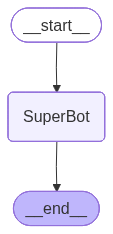

In [34]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [38]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is vishal And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is vishal And I like cricket', additional_kwargs={}, response_metadata={}, id='362a6bd3-61fe-4805-91b9-765538f0f54c'),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Vishal and mentioned they like cricket. I should start by acknowledging their introduction and expressing that I'm glad to meet them. Cricket is a shared interest since I'm an AI developed by Alibaba Cloud, and I have knowledge about various topics, including sports. I can ask them about their favorite team or player to keep the conversation going and show genuine interest. I should make sure to keep the response friendly and encouraging so they feel comfortable to continue the chat. Let me check if there's anything else I need to add. Maybe mention that I can share information about cricket or discuss strategies if they're interested. Yeah, that should cover it.\n</think>\n\nHello Vishal! Nice to meet you. 🏏 I'm glad to hear you like cricket—that's one 

In [40]:
for event in graph_builder.stream({"messages":"Hello My name is vishal"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Vishal. I should respond warmly to acknowledge their name. Maybe ask how I can assist them today. Keep it friendly and open-ended. Let them know I'm here to help with whatever they need. Make sure the tone is welcoming.\n</think>\n\nHello Vishal! Nice to meet you! 😊 How can I assist you today? Whether you have a question, need help with something, or just want to chat, I'm here for you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 15, 'total_tokens': 116, 'completion_time': 0.197111011, 'completion_tokens_details': None, 'prompt_time': 0.000515172, 'prompt_tokens_details': None, 'queue_time': 0.046798217, 'total_time': 0.197626183}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cf10b-7e4d-76c3-a233-2